In [1]:
import pandas as pd
import matplotlib as plt
import plotly.express as px
import seaborn as sns

MASTER_DF_PATH = './master_df.csv'
MASTER_DF_HS_PATH = './master_df_hs.csv'
MASTER_DF_ELEM_PATH = './master_df_elem.csv'

In [2]:
master_df = pd.read_csv(MASTER_DF_PATH)
master_df_hs = pd.read_csv(MASTER_DF_HS_PATH)
master_df_elem = pd.read_csv(MASTER_DF_ELEM_PATH)

In [3]:
male = master_df['total_enrollment_male'].sum()
female = master_df['total_enrollment_female'].sum()

print(f'Total Male Student K-12 Enrollment: {male:,}')
print(f'Total Female Student K-12 Enrollment: {female:,}')
print(f'Total Students K-12 Enrollment: {male + female:,}')

# Values less than 0 indicate missing data, -9 means not applicable/skipped
print(f"Schools missing Male enrollment data: {master_df[master_df['total_enrollment_male'] < 0]['COMBOKEY'].count()}")
print(f"Schools missing Female enrollment data: {master_df[master_df['total_enrollment_female'] < 0]['COMBOKEY'].count()}")

Total Male Student K-12 Enrollment: 20,272,493
Total Female Student K-12 Enrollment: 19,129,372
Total Students K-12 Enrollment: 39,401,865
Schools missing Male enrollment data: 0
Schools missing Female enrollment data: 0


In [4]:
# Teacher Salary Analysis

teacher_salary = master_df['teacher_salary_expend']

mean_value = teacher_salary.mean()         # Mean (average)
median_value = teacher_salary.median()      # Median
std_dev = teacher_salary.std()              # Standard deviation
min_value = teacher_salary.min()            # Minimum
max_value = teacher_salary.max()            # Maximum
count_value = teacher_salary.count()        # Count of non-NaN values

print(f'Mean National K-12 Teacher Salary Expenditures: ${mean_value:,.0f}')
print(f'Median National K-12 Teacher Salary Expenditures: ${median_value:,.0f}')
print(f'Standard Deviation of National K-12 Teacher Salary Expenditures: {std_dev:,.0f}')
print(f'Minimum National K-12 Teacher Salary Expenditures: ${min_value:,.0f}')
print(f'Maximum National K-12 Teacher Salary Expenditures: ${max_value:,.0f}')
print(f'Count of National K-12 Teacher Salary Expenditures: {count_value:,.0f}')

print()

teacher_count = master_df[master_df['teachers_fte'] > 0]['teachers_fte']

mean_value = teacher_count.mean()         # Mean (average)
median_value = teacher_count.median()      # Median
std_dev = teacher_count.std()              # Standard deviation
min_value = teacher_count.min()            # Minimum
max_value = teacher_count.max()            # Maximum

print(f'Mean National K-12 Teacher Count: {mean_value:,.0f}')
print(f'Median National K-12 Teacher Count: {median_value:,.0f}')
print(f'Standard Deviation of Teacher Count: {std_dev:,.0f}')
print(f'Minimum National K-12 Teacher Count: {min_value:,.0f}')
print(f'Maximum National K-12 Teacher Count: {max_value:,.0f}')


Mean National K-12 Teacher Salary Expenditures: $2,168,147
Median National K-12 Teacher Salary Expenditures: $1,744,948
Standard Deviation of National K-12 Teacher Salary Expenditures: 1,684,247
Minimum National K-12 Teacher Salary Expenditures: $0
Maximum National K-12 Teacher Salary Expenditures: $31,268,240
Count of National K-12 Teacher Salary Expenditures: 64,311

Mean National K-12 Teacher Count: 40
Median National K-12 Teacher Count: 33
Standard Deviation of Teacher Count: 25
Minimum National K-12 Teacher Count: 10
Maximum National K-12 Teacher Count: 305


In [5]:
# Reusable function to plot a feature by state
def plot_feature_by_state(feature, n=10, min = 0, max=100_000, top = True):
    if top:
        top_n = master_df.groupby('LEA_STATE')[feature].mean().nlargest(n)
        type = 'Top'
    else:
        top_n = master_df.groupby('LEA_STATE')[feature].mean().nsmallest(n)
        type = 'Bottom'
    top_n = top_n.reset_index()

    fig = px.bar(top_n, x='LEA_STATE', y=feature, title=f'{type} {n} States by {feature}')
    fig.update_yaxes(range=[min, max])
    fig.show()

In [6]:
n = 10

plot_feature_by_state('teacher_salary_expend', n=n, min=0, max=4_000_000, top=True)

In [7]:
n = 10

plot_feature_by_state('teacher_salary_expend_fed', n=n, min=0, max=6_500_000, top=True)

In [8]:
n = 10

plot_feature_by_state('average_teacher_salary', n, 50_000, 90_000)

In [9]:
n = 10

# Plot Bottom N States by Average Teacher Salary
plot_feature_by_state('average_teacher_salary', n, 30_000, 50_000, False)

In [10]:
n = 10

# Plot Top N States by Average Teacher Salary Adjusted
plot_feature_by_state('average_teacher_salary_adjusted', n, 50_000, 80_000)

In [11]:
n = 10

# Plot Bottom N States by Average Teacher Salary
plot_feature_by_state('average_teacher_salary_adjusted', n, 10_000, 50_000, False)

In [12]:
n = 50

# Plot Top N States by Average Teacher Salary
top_n_states = master_df[master_df['LEA_STATE'] == 'CA'].sort_values('average_teacher_salary', ascending=False).head(n)
top_n_states = top_n_states.reset_index()
top_n_states['COMBOKEY'] = top_n_states['COMBOKEY'].astype(str)
fig = px.bar(top_n_states, x='COMBOKEY', y='average_teacher_salary', title=f'California Outliers')
# set range to start at 60k
#fig.update_yaxes(range=[60_000, 160_000])
fig.show()

In [13]:
# Plotting the data
df = master_df.groupby('LEA_STATE')['average_teacher_salary'].mean().reset_index()
df['average_teacher_salary'] = df['average_teacher_salary'].round(0)

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="average_teacher_salary",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average Teacher Salary by State",
                    labels={'average_teacher_salary': ''})
fig.show()

In [14]:
# Plotting the data
df = master_df.groupby('LEA_STATE')['average_teacher_salary_adjusted'].mean().reset_index()

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="average_teacher_salary_adjusted",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average Teacher Salary by State (Adjusted for Cost of Living)",
                    labels={'average_teacher_salary_adjusted': ''})
fig.show()

In [15]:
# Plotting the data
df = master_df.groupby('LEA_STATE')['student_teacher_ratio'].mean().reset_index()

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="student_teacher_ratio",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average Student-Teacher Ratio by State",
                    labels={'student_teacher_ratio': ''})
fig.show()

In [16]:
# Plotting the data
df = master_df.groupby('LEA_STATE')['combined_proficiency_score_2018'].mean().reset_index()

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="combined_proficiency_score_2018",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average State Assessment Scores by State (2018)",
                    labels={'combined_proficiency_score_2018': ''})
fig.show()

In [17]:
# Plotting the data
df = master_df_hs.groupby('LEA_STATE')['reading_proficiency_score_2018'].mean().reset_index()

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="reading_proficiency_score_2018",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average State Reading Assessment Scores by State (2018)",
                    labels={'reading_proficiency_score_2018': ''})
fig.show()

In [18]:
# Plotting the data
df = master_df.groupby('LEA_STATE')['math_proficiency_score_2018'].mean().reset_index()

# Assuming df has 'State' as state abbreviations and 'Salary' as average teacher salary
fig = px.choropleth(df, locations="LEA_STATE", locationmode="USA-states", color="math_proficiency_score_2018",
                    scope="usa", color_continuous_scale="Hot_r",
                    title="Average State Math Assessment Scores by State (2018)",
                    labels={'math_proficiency_score_2018': ''})
fig.show()

In [19]:
import plotly.express as px

# Calculate combined chronic absences as the mean of male and female columns
master_df['chronic_absences_combined'] = master_df[['chronic_absences_male', 'chronic_absences_female']].mean(axis=1)

# Group by state and calculate the mean for chronic absences and other variables as needed
df = master_df.groupby('LEA_STATE').agg({
    'chronic_absences_combined': 'mean',
}).reset_index()


# Create the choropleth map for chronic absences
fig = px.choropleth(df,locations="LEA_STATE", 
                    locationmode="USA-states", 
                    color="chronic_absences_combined",
                    scope="usa", 
                    color_continuous_scale="Hot_r",
                    title="Average Chronic Absences by State",
                    labels={'chronic_absences_combined':''}
)
fig.show()

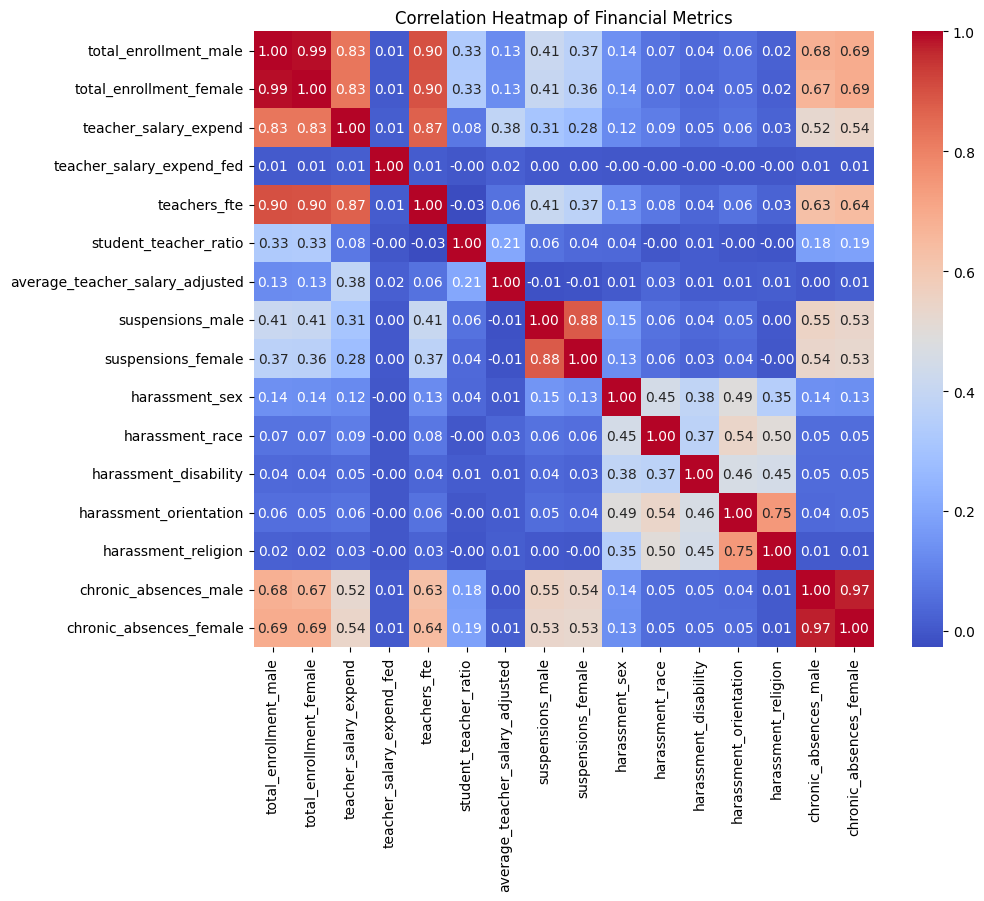

In [22]:
import matplotlib.pyplot as plt_py
# Create a visualization
# Select numerical columns for correlation analysis
numeric_columns = [
    'total_enrollment_male',
    'total_enrollment_female',
    'teacher_salary_expend', 
    'teacher_salary_expend_fed',
    'teachers_fte', 
    'student_teacher_ratio',
    'average_teacher_salary_adjusted', 
    'suspensions_male',
    'suspensions_female',
    'harassment_sex',
    'harassment_race',
    'harassment_disability',
    'harassment_orientation',
    'harassment_religion',
    'chronic_absences_male',
    'chronic_absences_female'
]

# Calculate the correlation matrix
correlation_matrix = master_df[numeric_columns].corr()

# Plot the heatmap
plt_py.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt_py.title('Correlation Heatmap of Financial Metrics')
plt_py.show()

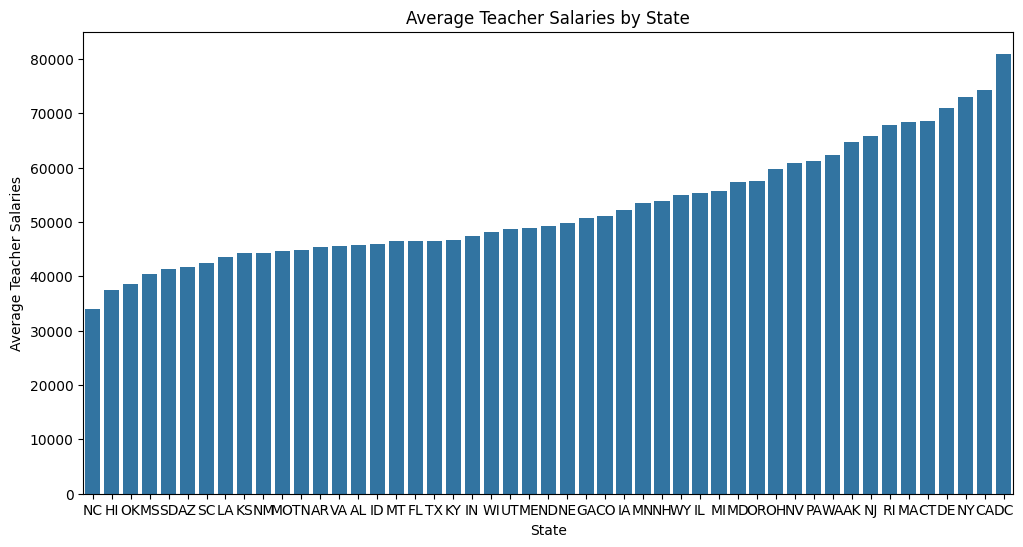

In [23]:
# Bar plot to show the average teacher salaries by state
plt_py.figure(figsize=(12, 6))
avg_salaries_by_state = master_df.groupby('LEA_STATE')['average_teacher_salary'].mean().reset_index()
avg_salaries_by_state = avg_salaries_by_state.sort_values(by='average_teacher_salary', ascending=True)
sns.barplot(x='LEA_STATE', y='average_teacher_salary', data=avg_salaries_by_state)
plt_py.title('Average Teacher Salaries by State')
plt_py.xlabel('State')
plt_py.ylabel('Average Teacher Salaries')
# set x tick to state names
#plt_py.xticks(ticks=avg_salaries_by_state['fips'], labels=[fips_to_state[int(fips)] for fips in avg_salaries_by_state['fips']], rotation=90)
plt_py.show()

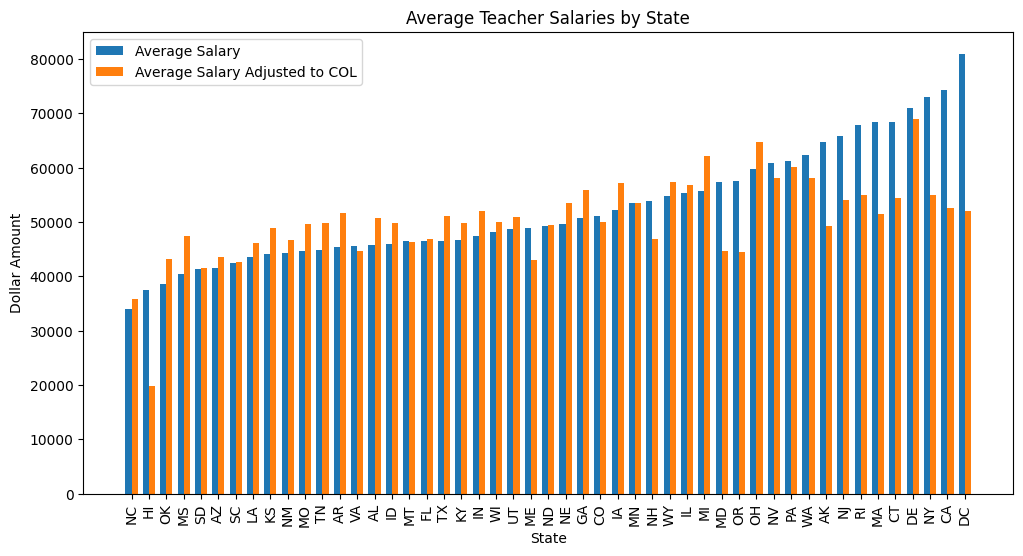

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame setup
# Replace master_df with your actual DataFrame variable if it's already defined
# master_df = pd.read_csv("path_to_your_data.csv")  # Uncomment if you need to load the data

# Bar plot to show the average teacher salaries by state
plt.figure(figsize=(12, 6))

# Group by 'LEA_STATE' and calculate the mean for each column
avg_salaries_by_state = master_df.groupby('LEA_STATE')[['average_teacher_salary', 'average_teacher_salary_adjusted']].mean().reset_index()

# Sort by 'average_teacher_salary' for ordered bar plot
avg_salaries_by_state = avg_salaries_by_state.sort_values(by='average_teacher_salary', ascending=True)

# Define the positions and width for the bars
bar_width = 0.35
x = np.arange(len(avg_salaries_by_state))  # x locations for the bars

# Create dual bar plot
plt.bar(x - bar_width/2, avg_salaries_by_state['average_teacher_salary'], width=bar_width, label='Average Salary')
plt.bar(x + bar_width/2, avg_salaries_by_state['average_teacher_salary_adjusted'], width=bar_width, label='Average Salary Adjusted to COL')

# Add labels and title
plt.title('Average Teacher Salaries by State')
plt.xlabel('State')
plt.ylabel('Dollar Amount')

# Set x-ticks to state names
plt.xticks(ticks=x, labels=avg_salaries_by_state['LEA_STATE'], rotation=90)

# Add legend
plt.legend()

# Display the plot
plt.show()

In [25]:
from PIL import Image

# Open the images you want to combine
img1 = Image.open('avg_teach_salary.png')
img2 = Image.open('avg_teach_salary_adjusted.png')
img3 = Image.open('avg_student_teach_ratio.png')
img4 = Image.open('avg_chronic_absence.png')
img5 = Image.open('avg_math_scores.png')
img6 = Image.open('avg_reading_scores.png')

# Get the dimensions of each image
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size
width4, height4 = img4.size
width5, height5 = img5.size
width6, height6 = img6.size


# Calculate the total width and height needed for the 2x2 grid
width = max(width1, width2, width3, width4, width5, width6)
height = max(height1, height2, height3, height4, height5, height6)

# Create a blank image with the calculated size
combined_img = Image.new('RGB', (width * 3, height * 2))

# Paste each image into the correct position
combined_img.paste(img1, (0, 0))  # Top-left
combined_img.paste(img2, (max(width1, width3), 0))  # Top-right
combined_img.paste(img3, (0, max(height1, height2)))  # Bottom-left
combined_img.paste(img4, (max(width1, width3), max(height1, height2)))  # Bottom-right
combined_img.paste(img5, (max(width1, width3) * 2, 0))
combined_img.paste(img6, (max(width1, width3) * 2, max(height1, height2)))

# Save or display the combined image
combined_img.save('combined_image.png')
#combined_img.show()